In [1]:
from simulation import citygraph_dataset
from learning import inductive_route_learning, eval_route_generator, bee_colony
from learning.bee_colony import main as main_bee  # я так обозвал
from learning.eval_route_generator import main as main_eval # я так обозвал
from omegaconf import OmegaConf, DictConfig
from simulation import drawing

from tqdm import tqdm
from pathlib import Path

In [2]:
from hydra import initialize_config_dir, compose
from omegaconf import OmegaConf
import os

cfg_dir = os.path.abspath("../TNDP_learning/cfg")

### Стартовый набор маршрутов

In [3]:
dataset_name = 'kem'
demand_time_weight = 0.33
route_time_weight = 0.33
median_connectivity_weight = 0.33
experiment_name = f'Kemerovo_exp_{dataset_name}_pp_{demand_time_weight}_op_{route_time_weight}_cp_{median_connectivity_weight}'
initial_routes_name = experiment_name+ '_starting'
generated_routes_name = experiment_name + '_generated'

In [4]:
with initialize_config_dir(config_dir=cfg_dir, version_base=None):
    
    cfg_eval = compose(
        config_name="eval_model_mumford",   # из @hydra.main
        overrides=[
            f"+eval={dataset_name}", # конфиг в котором задается кол-во маршрутов и их макс и мин длины (можно заменить на vo для теста по ваське)
            "+model.weights=../TNDP_learning/output/inductive_random_graphs.pt", # путь к весам модели
            f"++run_name={initial_routes_name}", # имя запуска, вернет pickle файл с тензором в output_routes
            f"++experiment.cost_function.kwargs.demand_time_weight={demand_time_weight}",
            f"++experiment.cost_function.kwargs.route_time_weight={route_time_weight}",
            f"++experiment.cost_function.kwargs.median_connectivity_weight={median_connectivity_weight}"
        ]
    )

In [5]:
print(OmegaConf.to_yaml(cfg_eval)) # чисто проверка как выглядит конфиг 

experiment:
  logdir: null
  anomaly: false
  cpu: false
  seed: 0
  symmetric_routes: true
  cost_function:
    type: mine
    kwargs:
      mean_stop_time_s: 0
      avg_transfer_wait_time_s: 300
      demand_time_weight: 0.33
      route_time_weight: 0.33
      median_connectivity_weight: 0.33
      constraint_violation_weight: 5.0
      variable_weights: true
      pp_fraction: 0.15
      op_fraction: 0.15
      mcw_fraction: 0.15
model:
  common:
    dropout: 0.0
    nonlin_type: ReLU
    embed_dim: 64
  route_generator:
    kwargs:
      force_linking_unlinked: false
      logit_clip: null
      n_nodepair_layers: 3
      n_pathscorer_layers: 3
      pathscorer_hidden_dim: 16
      n_halt_layers: 3
      halt_scorer_type: endpoints
      serial_halting: true
    type: PathCombiningRouteGenerator
  backbone_gn:
    net_type: graph attn
    kwargs:
      n_layers: 5
      in_node_dim: 4
      in_edge_dim: 14
      use_norm: false
      n_heads: 4
      dense: false
  weights: ../TN

In [6]:
import torch
print("Allocated:", torch.cuda.memory_allocated() / 1024**2, "MB")
print("Reserved: ", torch.cuda.memory_reserved() / 1024**2, "MB")


Allocated: 0.0 MB
Reserved:  0.0 MB


In [7]:
torch.cuda.empty_cache()
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()


In [8]:
metrics, unserved_demand = main_eval(cfg_eval)

/home/ruslan/TNDP_learning/learning/utils.py:321: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand,  metrics)


In [9]:
metrics

{'cost': tensor([4.7016], device='cuda:0'),
 'ATT': tensor([2499.9878], device='cuda:0'),
 'RTT': tensor([130906.8047], device='cuda:0'),
 '$d_0$': tensor([4.2006], device='cuda:0'),
 '$d_1$': tensor([8.4650], device='cuda:0'),
 '$d_2$': tensor([9.2343], device='cuda:0'),
 '$d_{un}$': tensor([78.1001], device='cuda:0'),
 '# disconnected node pairs': tensor([26443.], device='cuda:0'),
 '# stops out of bounds': tensor([0.], device='cuda:0'),
 'median_connectivity': tensor([135469.0469], device='cuda:0'),
 'average wall-clock duration': tensor([486.2609], device='cuda:0'),
 'average # iterations': tensor([0.], device='cuda:0')}

In [ ]:
metrics

{'cost': tensor([0.5241], device='cuda:0'),
 'ATT': tensor([13.6786], device='cuda:0'),
 'RTT': tensor([506.9600], device='cuda:0'),
 '$d_0$': tensor([29.7362], device='cuda:0'),
 '$d_1$': tensor([58.2219], device='cuda:0'),
 '$d_2$': tensor([11.7393], device='cuda:0'),
 '$d_{un}$': tensor([0.3026], device='cuda:0'),
 '# disconnected node pairs': tensor([0.], device='cuda:0'),
 '# stops out of bounds': tensor([0.], device='cuda:0'),
 'median_connectivity': tensor([580.7999], device='cuda:0'),
 'average wall-clock duration': tensor([88.3640], device='cuda:0'),
 'average # iterations': tensor([0.], device='cuda:0')}

Загружено узлов: 344
Размер матрицы времен: torch.Size([344, 344])
=== АНАЛИЗ ИСХОДНОЙ МАТРИЦЫ ===
Общее количество возможных ребер: 117992
Количество существующих ребер: 2628
Плотность графа: 2.23%

Найдено компонент связности: 2
Компонента 1: 342 узлов - [0, 1, 3, 5, 7, 9, 11, 12, 10, 14, 22, 26, 36, 31, 44, 47, 48, 49, 8, 6, 4, 2, 54, 63, 66, 77, 90, 68, 76, 67, 87, 89, 81, 74, 71, 57, 50, 25, 19, 13, 17, 20, 23, 29, 30, 18, 15, 21, 16, 27, 24, 28, 32, 35, 40, 41, 38, 37, 33, 43, 46, 53, 59, 72, 51, 79, 86, 95, 108, 112, 113, 97, 83, 69, 62, 52, 58, 96, 98, 99, 105, 100, 104, 117, 107, 123, 121, 114, 115, 127, 126, 132, 124, 116, 125, 130, 119, 106, 120, 146, 155, 147, 165, 143, 133, 139, 140, 136, 150, 148, 137, 118, 101, 84, 70, 56, 45, 42, 34, 61, 64, 65, 73, 80, 92, 94, 85, 82, 88, 93, 91, 78, 75, 39, 110, 103, 111, 102, 109, 129, 131, 138, 144, 145, 154, 142, 171, 161, 178, 180, 159, 135, 166, 196, 188, 193, 198, 214, 217, 212, 205, 202, 224, 228, 242, 240, 203, 179, 158, 249, 

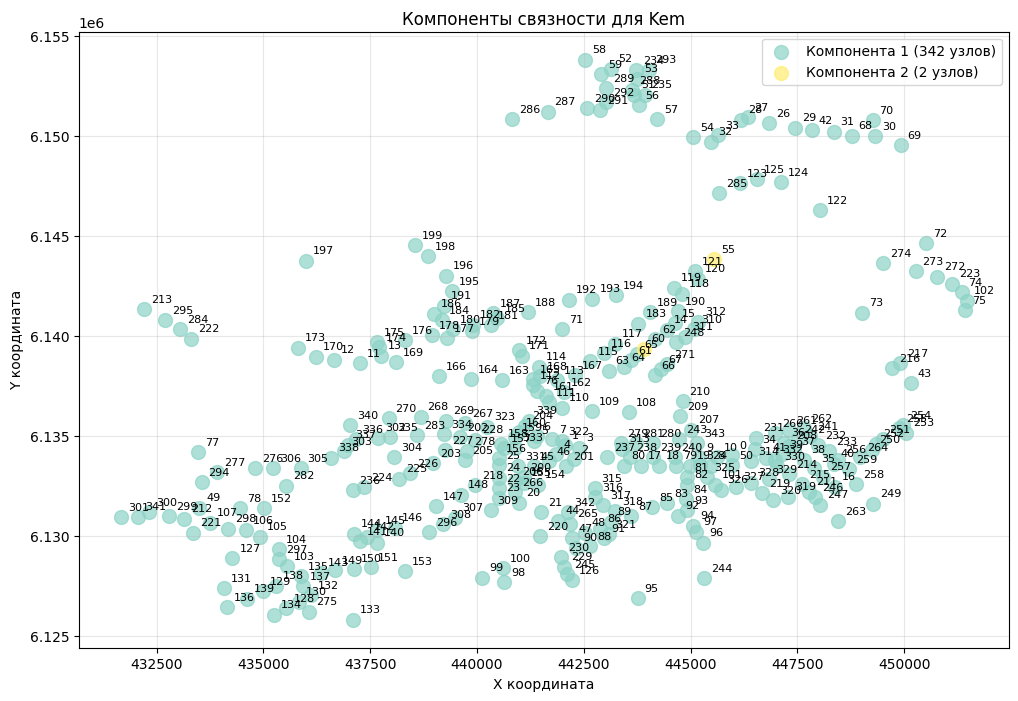


=== СОЕДИНЕНИЕ КОМПОНЕНТ ===

Соединяем 2 компонент...
Соединили узлы 65 ↔ 60: расстояние 312.90, время 0.52 мин

=== АНАЛИЗ ПОСЛЕ СОЕДИНЕНИЯ ===
Общее количество возможных ребер: 117992
Количество существующих ребер: 2630
Плотность графа: 2.23%

Найдено компонент связности: 1
Компонента 1: 344 узлов - [0, 1, 3, 5, 7, 9, 11, 12, 10, 14, 22, 26, 36, 31, 44, 47, 48, 49, 8, 6, 4, 2, 54, 63, 66, 77, 90, 68, 76, 67, 87, 89, 81, 74, 71, 57, 50, 25, 19, 13, 17, 20, 23, 29, 30, 18, 15, 21, 16, 27, 24, 28, 32, 35, 40, 41, 38, 37, 33, 43, 46, 53, 59, 72, 51, 79, 86, 95, 108, 112, 113, 97, 83, 69, 62, 52, 58, 96, 98, 99, 105, 100, 104, 117, 107, 123, 121, 114, 115, 127, 126, 132, 124, 116, 125, 130, 119, 106, 120, 146, 155, 147, 165, 143, 133, 139, 140, 136, 150, 148, 137, 118, 101, 84, 70, 56, 45, 42, 34, 61, 64, 65, 60, 55, 73, 80, 92, 94, 85, 82, 88, 93, 91, 78, 75, 39, 110, 103, 111, 102, 109, 129, 131, 138, 144, 145, 154, 142, 171, 161, 178, 180, 159, 135, 166, 196, 188, 193, 198, 214, 217,

In [11]:
import numpy as np
import torch
from pathlib import Path
import matplotlib.pyplot as plt

# Настройки
instance_name = 'Kem'  # Измените на нужный: Mandl, Mumford0, Mumford1, Mumford2, Mumford3
instances_dir = 'CEC2013Supp/Instances'  # Укажите путь к данным
assumed_speed_mps = 10  # м/с

# Загрузка данных
data_dir = Path(instances_dir)

# Загружаем координаты узлов
coords_path = data_dir / (instance_name + 'Coords.txt')
node_locs = torch.tensor(np.genfromtxt(coords_path, skip_header=1), dtype=torch.float32)
print(f"Загружено узлов: {node_locs.shape[0]}")

# Загружаем времена поездок
tt_path = data_dir / (instance_name + 'TravelTimes.txt')
street_edge_times_s = torch.tensor(np.genfromtxt(tt_path), dtype=torch.float32) * 60  # в секунды
print(f"Размер матрицы времен: {street_edge_times_s.shape}")

def analyze_connectivity(adj_matrix, node_positions):
    """Анализирует связность графа"""
    n_nodes = adj_matrix.shape[0]
    
    # Создаем граф смежности
    graph = (adj_matrix > 0) & adj_matrix.isfinite()
    
    print(f"Общее количество возможных ребер: {n_nodes * (n_nodes - 1)}")
    print(f"Количество существующих ребер: {graph.sum().item()}")
    print(f"Плотность графа: {graph.sum().item() / (n_nodes * (n_nodes - 1)) * 100:.2f}%")
    
    # Находим компоненты связности
    visited = torch.zeros(n_nodes, dtype=torch.bool)
    components = []
    
    def dfs(node, component):
        visited[node] = True
        component.append(node)
        for neighbor in range(n_nodes):
            if graph[node, neighbor] and not visited[neighbor]:
                dfs(neighbor, component)
    
    # Собираем все компоненты
    for i in range(n_nodes):
        if not visited[i]:
            component = []
            dfs(i, component)
            components.append(component)
    
    print(f"\nНайдено компонент связности: {len(components)}")
    
    # Подробная информация о компонентах
    for i, comp in enumerate(components):
        print(f"Компонента {i+1}: {len(comp)} узлов - {comp}")
    
    return components, graph

def visualize_components(node_positions, components):
    """Визуализация компонент связности"""
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(components)))
    
    for i, comp in enumerate(components):
        comp_positions = node_positions[comp]
        plt.scatter(comp_positions[:, 0], comp_positions[:, 1], 
                   c=[colors[i]], s=100, alpha=0.7, label=f'Компонента {i+1} ({len(comp)} узлов)')
        
        # Подписываем узлы
        for j, node_idx in enumerate(comp):
            plt.annotate(str(node_idx), 
                        (node_positions[node_idx, 0], node_positions[node_idx, 1]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.title(f'Компоненты связности для {instance_name}')
    plt.xlabel('X координата')
    plt.ylabel('Y координата')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def connect_components(adj_matrix, node_positions, components):
    """Соединяет компоненты кратчайшими расстояниями"""
    if len(components) <= 1:
        print("Граф уже связен!")
        return adj_matrix
    
    adj_matrix_connected = adj_matrix.clone()
    
    print(f"\nСоединяем {len(components)} компонент...")
    
    # Соединяем последовательно компоненты
    for i in range(len(components) - 1):
        comp1 = components[i]
        comp2 = components[i + 1]
        
        # Найдем ближайшие узлы
        min_dist = float('inf')
        best_pair = None
        
        for node1 in comp1:
            for node2 in comp2:
                dist = torch.norm(node_positions[node1] - node_positions[node2])
                if dist < min_dist:
                    min_dist = dist
                    best_pair = (node1, node2)
        
        if best_pair:
            n1, n2 = best_pair
            # Оцениваем время поездки (в минутах)
            travel_time_min = min_dist.item() / assumed_speed_mps / 60
            
            adj_matrix_connected[n1, n2] = travel_time_min
            adj_matrix_connected[n2, n1] = travel_time_min
            
            print(f"Соединили узлы {n1} ↔ {n2}: расстояние {min_dist:.2f}, время {travel_time_min:.2f} мин")
    
    return adj_matrix_connected

# Анализируем исходную матрицу
print("=== АНАЛИЗ ИСХОДНОЙ МАТРИЦЫ ===")
components, graph = analyze_connectivity(street_edge_times_s, node_locs)

# Визуализируем компоненты
visualize_components(node_locs, components)

# Соединяем компоненты если нужно
if len(components) > 1:
    print("\n=== СОЕДИНЕНИЕ КОМПОНЕНТ ===")
    street_edge_times_connected = connect_components(street_edge_times_s, node_locs, components)
    
    # Проверяем результат
    print("\n=== АНАЛИЗ ПОСЛЕ СОЕДИНЕНИЯ ===")
    new_components, new_graph = analyze_connectivity(street_edge_times_connected, node_locs)
    
    # Сохраняем результат
    output_path = data_dir / (instance_name + 'TravelTimes_Connected.txt')
    np.savetxt(output_path, street_edge_times_connected.numpy(), fmt='%.6f')
    print(f"\nСохранена связная матрица в: {output_path}")
    
else:
    print("\nГраф уже связен, дополнительные ребра не нужны.")

# Дополнительная статистика
print(f"\n=== СТАТИСТИКА ===")
non_zero = (street_edge_times_s > 0) & street_edge_times_s.isfinite()
print(f"Минимальное время поездки: {street_edge_times_s[non_zero].min():.2f} с")
print(f"Максимальное время поездки: {street_edge_times_s[non_zero].max():.2f} с")
print(f"Среднее время поездки: {street_edge_times_s[non_zero].mean():.2f} с")

In [ ]:
unserved_demand

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')

In [ ]:
unserved_demand

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')

### Генерация 

In [12]:
with initialize_config_dir(config_dir=cfg_dir, version_base=None):
    cfg_neural = compose(
        config_name="neural_bco_mumford",
        overrides=[
            f"+eval={dataset_name}", # конфиг в котором задается кол-во маршрутов и их макс и мин длины (можно заменить на vo для теста по ваське)
            "+model.weights=../TNDP_learning/output/inductive_random_graphs.pt", # путь к весам модели
            f"++run_name={generated_routes_name}", # имя запуска, вернет pickle файл с тензором в output_routes
            f"++experiment.cost_function.kwargs.demand_time_weight={demand_time_weight}",
            f"++experiment.cost_function.kwargs.route_time_weight={route_time_weight}",
            f"++experiment.cost_function.kwargs.median_connectivity_weight={median_connectivity_weight}",
            f"init.path=output_routes/nn_construction_{initial_routes_name}_routes.pkl",
        ]
    )

In [16]:
generated_routes_name

'Kemerovo_exp_kem_pp_0.33_op_0.33_cp_0.33_generated'

In [13]:
print(OmegaConf.to_yaml(cfg_neural)) # чисто проверка как выглядит конфиг 

n_bees: 10
n_iterations: 100
batch_size: 10
neural_bees: true
force_linking_unlinked: false
experiment:
  logdir: training_logs
  anomaly: false
  cpu: false
  seed: 0
  symmetric_routes: true
  cost_function:
    type: mine
    kwargs:
      mean_stop_time_s: 0
      avg_transfer_wait_time_s: 300
      demand_time_weight: 0.33
      route_time_weight: 0.33
      median_connectivity_weight: 0.33
      constraint_violation_weight: 5.0
      variable_weights: true
      pp_fraction: 0.15
      op_fraction: 0.15
      mcw_fraction: 0.15
model:
  common:
    dropout: 0.0
    nonlin_type: ReLU
    embed_dim: 64
  route_generator:
    kwargs:
      force_linking_unlinked: false
      logit_clip: null
      n_nodepair_layers: 3
      n_pathscorer_layers: 3
      pathscorer_hidden_dim: 16
      n_halt_layers: 3
      halt_scorer_type: endpoints
      serial_halting: true
    type: PathCombiningRouteGenerator
  backbone_gn:
    net_type: graph attn
    kwargs:
      n_layers: 5
      in_node_di

In [14]:
metrics, unserved_demand = main_bee(cfg_neural)

In [17]:
unserved_demand

tensor([[[  0.,   0., 168.,  ...,   0.,   0.,   0.],
         [  0.,   0.,  93.,  ...,   0.,   0.,   0.],
         [ 45., 130.,   0.,  ...,  27.,  34.,  26.],
         ...,
         [  0.,   0.,  11.,  ...,   0.,   0.,   0.],
         [  0.,   0.,  19.,  ...,   0.,   0.,   0.],
         [  0.,   0.,  59.,  ...,   0.,   0.,   0.]]], device='cuda:0')

In [15]:
metrics

{'cost': tensor([3.0611], device='cuda:0'),
 'ATT': tensor([2765.8948], device='cuda:0'),
 'RTT': tensor([140074.8125], device='cuda:0'),
 '$d_0$': tensor([4.7248], device='cuda:0'),
 '$d_1$': tensor([11.5212], device='cuda:0'),
 '$d_2$': tensor([15.8992], device='cuda:0'),
 '$d_{un}$': tensor([67.8547], device='cuda:0'),
 '# disconnected node pairs': tensor([14123.], device='cuda:0'),
 '# stops out of bounds': tensor([0.], device='cuda:0'),
 'median_connectivity': tensor([144526.9688], device='cuda:0'),
 'average wall-clock duration': tensor([7292.5654], device='cuda:0'),
 'average # iterations': tensor([101.], device='cuda:0')}

In [ ]:
metrics['median_connectivity'] /= 60 

In [ ]:
# Порядок нужных ключей
keys_order = ['ATT', 'RTT', 'median_connectivity', 'cost', '$d_{un}$', '$d_0$', '$d_1$', '$d_2$']

print('\t'.join(str(round(metrics[key].item(),3)) for key in keys_order))
print('\t'.join(str(round(metrics[key].item(),3)) for key in keys_order))

10.954	244.0	12.0	0.332	0.0	84.393	13.166	2.441
10.954	244.0	12.0	0.332	0.0	84.393	13.166	2.441


In [ ]:
import csv
from pathlib import Path
from hydra import initialize_config_dir, compose
from omegaconf import OmegaConf
from learning.eval_route_generator import main as main_eval
from learning.bee_colony import main as main_bee
from tqdm import tqdm

# Путь к конфигам
cfg_dir = Path("../TNDP_learning/cfg").resolve()

# Все параметры экспериментов
experiments = [
    ("mandl", 1, 0, 0),
    ("mandl", 0, 1, 0),
    ("mandl", 0, 0, 1),
    ("mandl", 0.5, 0.5, 0),
    ("mandl", 0.5, 0, 0.5),
    ("mandl", 0, 0.5, 0.5),
    ("mandl", 0.33, 0.33, 0.33),
    ("mumford0", 1, 0, 0),
    ("mumford0", 0, 1, 0),
    ("mumford0", 0, 0, 1),
    ("mumford0", 0.5, 0.5, 0),
    ("mumford0", 0.5, 0, 0.5),
    ("mumford0", 0, 0.5, 0.5),
    ("mumford0", 0.33, 0.33, 0.33),
    ("mumford1", 1, 0, 0),
    ("mumford1", 0, 1, 0),
    ("mumford1", 0, 0, 1),
    ("mumford1", 0.5, 0.5, 0),
    ("mumford1", 0.5, 0, 0.5),
    ("mumford1", 0, 0.5, 0.5),
    ("mumford1", 0.33, 0.33, 0.33),
    ("mumford2", 1, 0, 0),
    ("mumford2", 0, 1, 0),
    ("mumford2", 0, 0, 1),
    ("mumford2", 0.5, 0.5, 0),
    ("mumford2", 0.5, 0, 0.5),
    ("mumford2", 0, 0.5, 0.5),
    ("mumford2", 0.33, 0.33, 0.33),
    ("mumford3", 1, 0, 0),
    ("mumford3", 0, 1, 0),
    ("mumford3", 0, 0, 1),
    ("mumford3", 0.5, 0.5, 0),
    ("mumford3", 0.5, 0, 0.5),
    ("mumford3", 0, 0.5, 0.5),
    ("mumford3", 0.33, 0.33, 0.33),
]

# Путь к весам модели
model_weights_path = "../TNDP_learning/output/inductive_random_graphs_checkpoints/iter990.pt"

# CSV файл для результатов
results_file = Path("experiment_results.csv")
if not results_file.exists():
    with open(results_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            "dataset", "demand_time", "route_time", "connectivity",
            "ATT", "RTT", "median_connectivity", "cost", "$d_{un}$", "$d_0$", "$d_1$", "$d_2$"
        ])

# Запуск экспериментов с tqdm
for dataset_name, dt, rt, ct in tqdm(experiments, desc="Running experiments"):
    try:
        experiment_name = f"exp_{dataset_name}_pp_{dt}_op_{rt}_cp_{ct}"
        initial_routes_name = experiment_name + '_starting'
        generated_routes_name = experiment_name + '_generated'

        with initialize_config_dir(config_dir=str(cfg_dir), version_base=None):
            cfg_eval = compose(
                config_name="eval_model_mumford",
                overrides=[
                    f"+eval={dataset_name.lower()}",
                    f"+model.weights={model_weights_path}",
                    f"++run_name={initial_routes_name}",
                    f"++experiment.cost_function.kwargs.demand_time_weight={dt}",
                    f"++experiment.cost_function.kwargs.route_time_weight={rt}",
                    f"++experiment.cost_function.kwargs.median_connectivity_weight={ct}"
                ]
            )
        eval_metrics, unserved_demand = main_eval(cfg_eval)

        with initialize_config_dir(config_dir=str(cfg_dir), version_base=None):
            cfg_bee = compose(
                config_name="neural_bco_mumford",
                overrides=[
                    f"+eval={dataset_name.lower()}",
                    f"+model.weights={model_weights_path}",
                    f"++run_name={generated_routes_name}",
                    f"++experiment.cost_function.kwargs.demand_time_weight={dt}",
                    f"++experiment.cost_function.kwargs.route_time_weight={rt}",
                    f"++experiment.cost_function.kwargs.median_connectivity_weight={ct}",
                    f"init.path=output_routes/nn_construction_{initial_routes_name}_routes.pkl",
                ]
            )
        bee_metrics, unserved_demand = main_bee(cfg_bee)
        bee_metrics['median_connectivity'] /= 60

        keys_order = ['ATT', 'RTT', 'median_connectivity', 'cost', '$d_{un}$', '$d_0$', '$d_1$', '$d_2$']
        row = [dataset_name.lower(), dt, rt, ct] + [round(bee_metrics[k].item(), 4) for k in keys_order]

        with open(results_file, mode='a', newline='') as f:
            csv.writer(f).writerow(row)

    except Exception as e:
        print(f"[✗] Failed {experiment_name}: {e}")

Running experiments:   0%|          | 0/35 [00:00<?, ?it/s]

/root/TNDP_learning/learning/utils.py:320: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  out_stats = (final_costs.mean(), final_costs.std(), metrics)
Running experiments:  57%|█████▋    | 20/35 [16:15:46<12:11:49, 2927.32s/it]


KeyboardInterrupt: 

In [ ]:
# Эксперименты только с mandl
import csv
from pathlib import Path
from hydra import initialize_config_dir, compose
from learning.eval_route_generator import main as main_eval
from tqdm import tqdm

model_weights_path = "../TNDP_learning/output/inductive_random_graphs_checkpoints/iter990.pt"

mandl_experiments = [
    ("mandl", 1, 0, 0),
    ("mandl", 0, 1, 0),
    ("mandl", 0, 0, 1),
    ("mandl", 0.5, 0.5, 0),
    ("mandl", 0.5, 0, 0.5),
    ("mandl", 0, 0.5, 0.5),
    ("mandl", 0.33, 0.33, 0.33),
]

# CSV файл
results_file = Path("eval_only_mandl.csv")
if not results_file.exists():
    with open(results_file, mode='w', newline='') as f:
        csv.writer(f).writerow([
            "dataset", "demand_time", "route_time", "connectivity",
            "ATT", "RTT", "median_connectivity", "cost", "$d_{un}$", "$d_0$", "$d_1$", "$d_2$"
        ])

# Запуск экспериментов только main_eval
for dataset_name, dt, rt, ct in tqdm(mandl_experiments, desc="Evaluating mandl"):
    try:
        run_name = f"mandl_eval_pp_{dt}_op_{rt}_cp_{ct}"

        with initialize_config_dir(config_dir=str(cfg_dir), version_base=None):
            cfg_eval = compose(
                config_name="eval_model_mumford",
                overrides=[
                    f"+eval={dataset_name}",
                    f"+model.weights={model_weights_path}",
                    f"++run_name={run_name}",
                    f"++experiment.cost_function.kwargs.demand_time_weight={dt}",
                    f"++experiment.cost_function.kwargs.route_time_weight={rt}",
                    f"++experiment.cost_function.kwargs.median_connectivity_weight={ct}",
                ]
            )

        metrics = main_eval(cfg_eval)
        keys_order = ['ATT', 'RTT', 'median_connectivity', 'cost', '$d_{un}$', '$d_0$', '$d_1$', '$d_2$']
        row = [dataset_name, dt, rt, ct] + [round(metrics[k].item(), 4) for k in keys_order]

        with open(results_file, mode='a', newline='') as f:
            csv.writer(f).writerow(row)

    except Exception as e:
        print(f"[✗] Failed eval for {run_name}: {e}")

Evaluating mandl:   0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.63s/it]
/root/TNDP_learning/learning/utils.py:320: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  out_stats = (final_costs.mean(), final_costs.std(), metrics)
Evaluating mandl:  14%|█▍        | 1/7 [00:01<00:11,  1.87s/it]

,6.000,0.332,10.954,244.000,84.393,13.166,2.441,0.000,0.000,0.000,720.000,1.621,0.000
{'cost': tensor([0.3319]), 'ATT': tensor([10.9538]), 'RTT': tensor([244.]), '$d_0$': tensor([84.3931]), '$d_1$': tensor([13.1663]), '$d_2$': tensor([2.4406]), '$d_{un}$': tensor([0.]), '# disconnected node pairs': tensor([0.]), '# stops out of bounds': tensor([0.]), 'median_connectivity': tensor([720.]), 'average wall-clock duration': tensor([1.6207]), 'average # iterations': tensor([0.])}


100%|██████████| 1/1 [00:00<00:00, -1.44it/s]


,6.000,0.747,13.493,148.000,59.216,36.609,4.110,0.064,0.000,0.000,868.000,-0.701,0.000
{'cost': tensor([0.7475]), 'ATT': tensor([13.4926]), 'RTT': tensor([148.]), '$d_0$': tensor([59.2164]), '$d_1$': tensor([36.6089]), '$d_2$': tensor([4.1105]), '$d_{un}$': tensor([0.0642]), '# disconnected node pairs': tensor([0.]), '# stops out of bounds': tensor([0.]), 'median_connectivity': tensor([868.]), 'average wall-clock duration': tensor([-0.7006]), 'average # iterations': tensor([0.])}


...

,6.000,0.348,10.954,244.000,84.393,13.166,2.441,0.000,0.000,0.000,720.000,1.601,0.000
{'cost': tensor([0.3478]), 'ATT': tensor([10.9538]), 'RTT': tensor([244.]), '$d_0$': tensor([84.3931]), '$d_1$': tensor([13.1663]), '$d_2$': tensor([2.4406]), '$d_{un}$': tensor([0.]), '# disconnected node pairs': tensor([0.]), '# stops out of bounds': tensor([0.]), 'median_connectivity': tensor([720.]), 'average wall-clock duration': tensor([1.6012]), 'average # iterations': tensor([0.])}


Evaluating mandl:  86%|████████▌ | 6/7 [00:08<00:01,  1.47s/it]

,6.000,0.590,13.248,152.000,59.409,39.435,1.156,0.000,0.000,0.000,816.000,1.597,0.000
{'cost': tensor([0.5899]), 'ATT': tensor([13.2479]), 'RTT': tensor([152.]), '$d_0$': tensor([59.4091]), '$d_1$': tensor([39.4348]), '$d_2$': tensor([1.1561]), '$d_{un}$': tensor([0.]), '# disconnected node pairs': tensor([0.]), '# stops out of bounds': tensor([0.]), 'median_connectivity': tensor([816.]), 'average wall-clock duration': tensor([1.5967]), 'average # iterations': tensor([0.])}


Evaluating mandl: 100%|██████████| 7/7 [00:09<00:00,  1.41s/it]

,6.000,0.524,12.087,164.000,69.043,28.003,2.954,0.000,0.000,0.000,780.000,1.620,0.000
{'cost': tensor([0.5242]), 'ATT': tensor([12.0873]), 'RTT': tensor([164.]), '$d_0$': tensor([69.0430]), '$d_1$': tensor([28.0026]), '$d_2$': tensor([2.9544]), '$d_{un}$': tensor([0.]), '# disconnected node pairs': tensor([0.]), '# stops out of bounds': tensor([0.]), 'median_connectivity': tensor([780.]), 'average wall-clock duration': tensor([1.6195]), 'average # iterations': tensor([0.])}
